#Libraries

In [3]:
# ================================================
# SAUDI RETAIL SALES FORECASTING
# Notebook 3: Visualization & Charts
# ================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chart style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Blues_r")

print("✅ Libraries ready!")

✅ Libraries ready!


 Load Data

In [6]:
# Load clean data
df = pd.read_csv("/content/saudi_sales_clean.csv",
                  parse_dates=['date'])

# Load SQL results
yearly    = pd.read_csv("/content/sql_yearly_sales.csv")
monthly   = pd.read_csv("/content/sql_monthly_sales.csv")
growth    = pd.read_csv("/content/sql_yoy_growth.csv")
top10     = pd.read_csv("/content/sql_top10_months.csv")
quarterly = pd.read_csv("/content/sql_quarterly_sales.csv")

print("✅ All data loaded!")
print(f"📊 Main dataset: {df.shape[0]} rows")

✅ All data loaded!
📊 Main dataset: 135 rows


Chart 1: Sales Trend Over Time

ValueError: Format 'csv' is not supported (supported formats: eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff, webp)

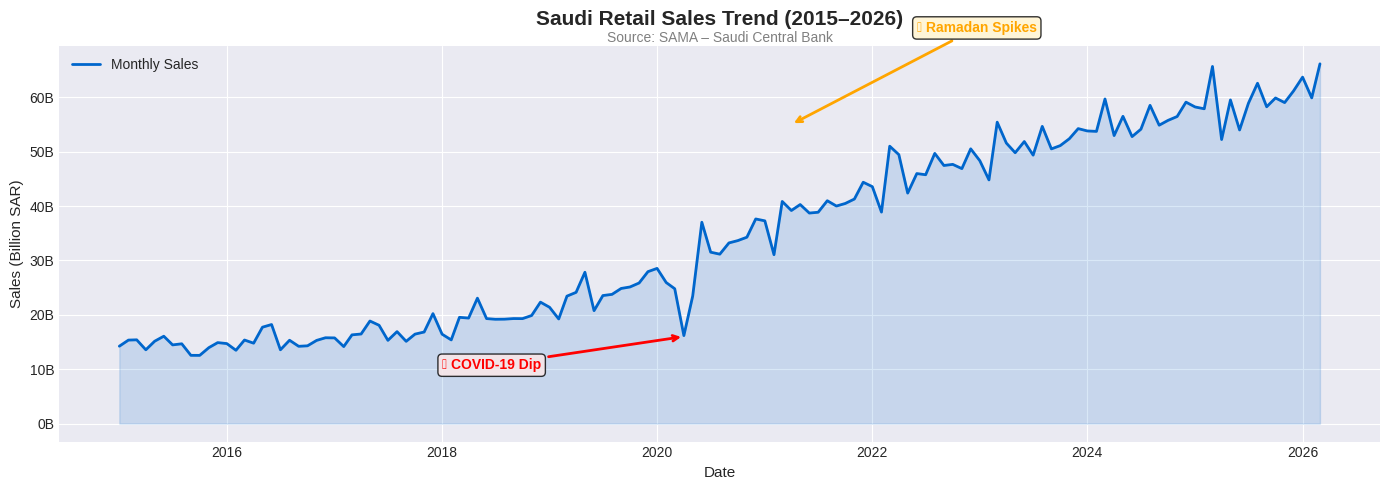

In [7]:
# ================================================
# CHART 1: Monthly Sales Trend (2015-2026)
# ================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['date'],
        df['sales_thousand_sar'] / 1000000,
        color='#0066CC', linewidth=2, label='Monthly Sales')

ax.fill_between(df['date'],
                df['sales_thousand_sar'] / 1000000,
                alpha=0.15, color='#0066CC')

# Fixed: moved annotations away from title
ax.annotate('🌙 Ramadan Spikes',
            xy=(pd.Timestamp('2021-04-01'), 55),
            xytext=(pd.Timestamp('2022-06-01'), 72),
            arrowprops=dict(arrowstyle='->', color='orange', lw=2),
            fontsize=10, color='orange', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3cd', alpha=0.8))

ax.annotate('😷 COVID-19 Dip',
            xy=(pd.Timestamp('2020-04-01'), 16),
            xytext=(pd.Timestamp('2018-01-01'), 10),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=10, color='red', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fde8e8', alpha=0.8))

ax.set_title('Saudi Retail Sales Trend (2015–2026)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_subtitle = ax.text(0.5, 1.01, 'Source: SAMA – Saudi Central Bank',
             transform=ax.transAxes, ha='center', fontsize=10, color='gray')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Sales (Billion SAR)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fB'))
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('/content/sql_monthly_sales.csv', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 fixed & saved!")

Chart 2: Yearly Sales Bar Chart

ValueError: Format 'csv' is not supported (supported formats: eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff, webp)

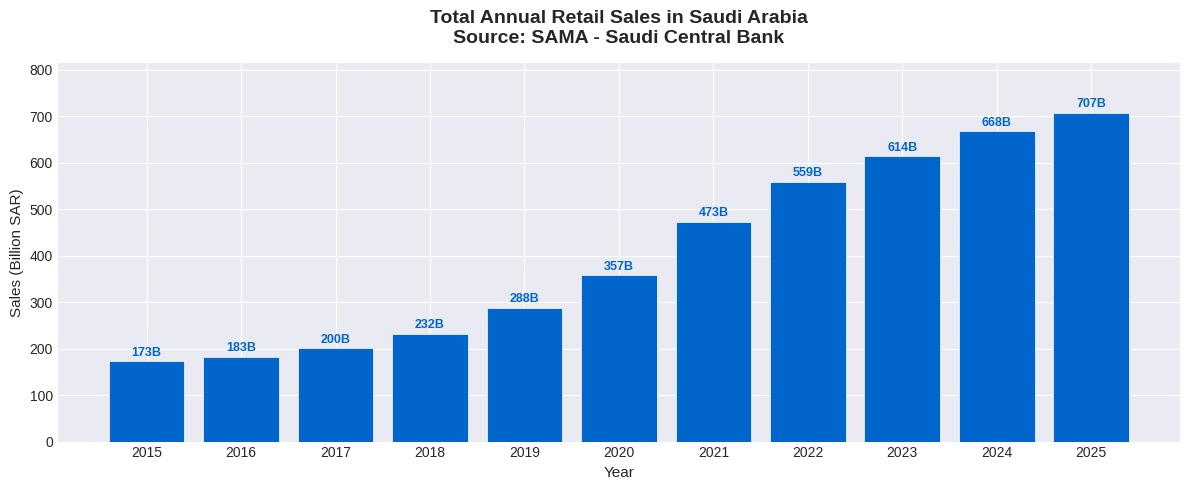

In [9]:
# ================================================
# CHART 2: Total Sales Per Year
# ================================================

# Exclude incomplete 2026
yearly_complete = yearly[yearly['months_recorded'] == 12]

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(yearly_complete['year'].astype(str),
              yearly_complete['total_sales_billion_sar'],
              color='#0066CC', edgecolor='white',
              linewidth=0.5)

# Add value labels on bars
for bar, val in zip(bars, yearly_complete['total_sales_billion_sar']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f'{val:.0f}B',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#0066CC')

ax.set_title('Total Annual Retail Sales in Saudi Arabia\nSource: SAMA - Saudi Central Bank',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Sales (Billion SAR)', fontsize=11)
ax.set_ylim(0, yearly_complete['total_sales_billion_sar'].max() * 1.15)

plt.tight_layout()
plt.savefig('/content/sql_yearly_sales.csv', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

Chart 3: Monthly Seasonality

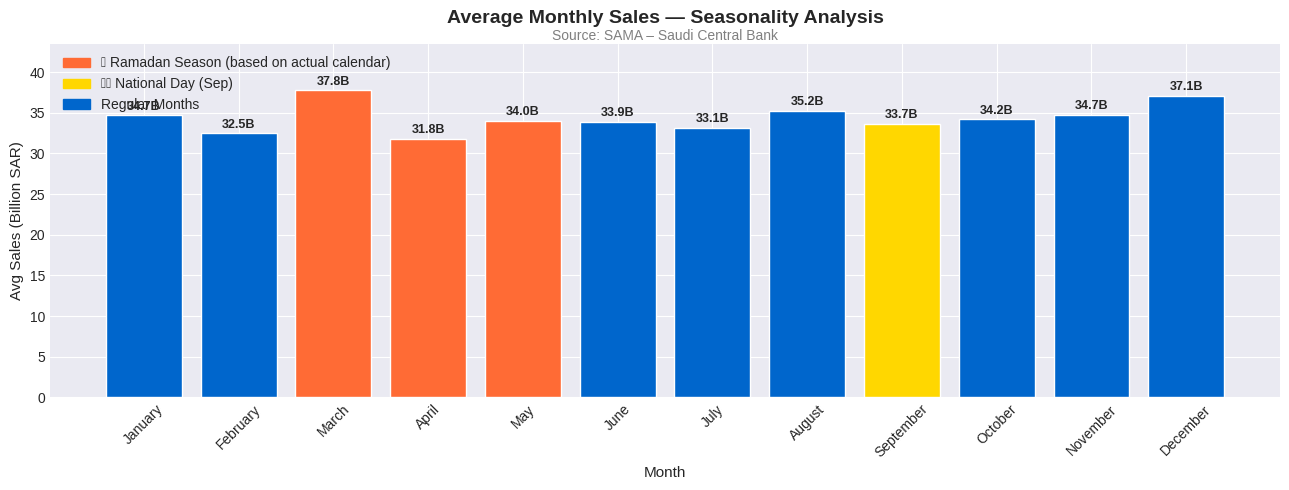

✅ Chart 3 fixed & saved!


In [10]:
# ================================================
# CHART 3: Which Month is Always Busiest?
# ================================================

# Ramadan approximate months per year (Islamic calendar)
ramadan_months = {
    2015: 7, 2016: 6, 2017: 5, 2018: 5,
    2019: 5, 2020: 4, 2021: 4, 2022: 4,
    2023: 3, 2024: 3, 2025: 3, 2026: 3
}

# Count how many times each month was Ramadan
from collections import Counter
ramadan_counts = Counter(ramadan_months.values())
# Months that were Ramadan 3+ times = mark as Ramadan season
ramadan_season_months = [m for m, c in ramadan_counts.items() if c >= 3]

monthly_sorted = monthly.sort_values('month')

colors = []
for m in monthly_sorted['month']:
    if m in ramadan_season_months:
        colors.append('#FF6B35')   # Ramadan
    elif m == 9:
        colors.append('#FFD700')   # National Day
    else:
        colors.append('#0066CC')   # Regular

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(monthly_sorted['month_name'],
              monthly_sorted['avg_sales_billion'],
              color=colors, edgecolor='white')

for bar, val in zip(bars, monthly_sorted['avg_sales_billion']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}B',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend = [
    Patch(color='#FF6B35', label='🌙 Ramadan Season (based on actual calendar)'),
    Patch(color='#FFD700', label='🇸🇦 National Day (Sep)'),
    Patch(color='#0066CC', label='Regular Months')
]
ax.legend(handles=legend, fontsize=10)

ax.set_title('Average Monthly Sales — Seasonality Analysis',
             fontsize=14, fontweight='bold', pad=15)
ax.text(0.5, 1.01, 'Source: SAMA – Saudi Central Bank',
        transform=ax.transAxes, ha='center', fontsize=10, color='gray')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Avg Sales (Billion SAR)', fontsize=11)
ax.set_ylim(0, monthly_sorted['avg_sales_billion'].max() * 1.15)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('/content/chart3_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 fixed & saved!")

Chart 4: Year over Year Growth

💡 Best:  2021 → +32.45%
💡 Worst: 2016 → +5.73%


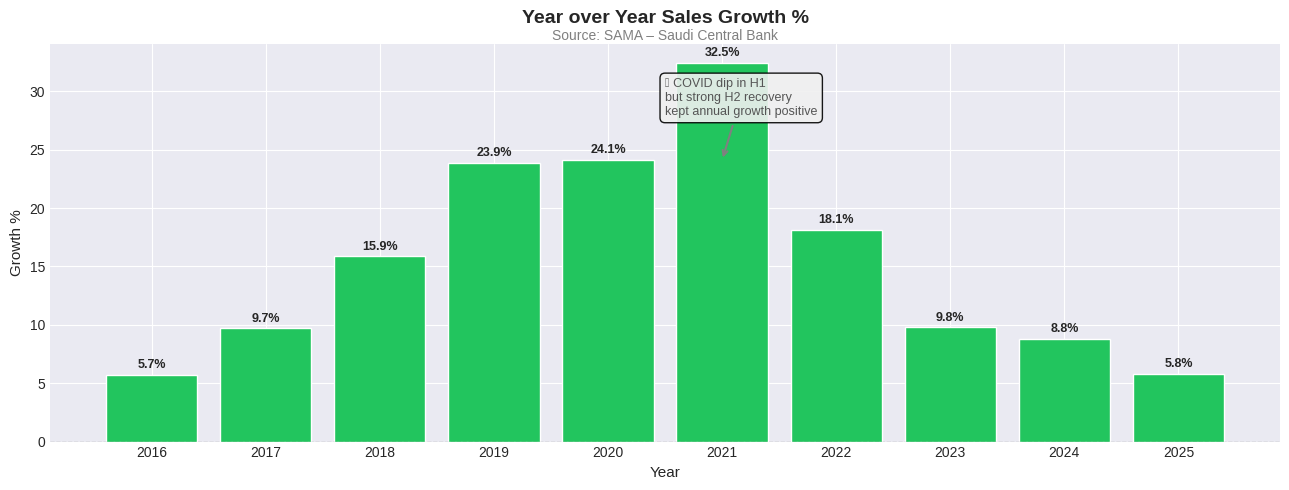

✅ Chart 4 fixed & saved!


In [11]:
# ================================================
# CHART 4: Year over Year Growth %
# ================================================

growth_complete = growth[growth['year_status'] == 'Complete Year'].dropna()

fig, ax = plt.subplots(figsize=(13, 5))

colors = ['#22c55e' if g > 0 else '#ef4444'
          for g in growth_complete['growth_percent']]

bars = ax.bar(growth_complete['year'].astype(str),
              growth_complete['growth_percent'],
              color=colors, edgecolor='white')

for bar, val in zip(bars, growth_complete['growth_percent']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# Fixed: explain the 2020 anomaly clearly
ax.annotate('😷 COVID dip in H1\nbut strong H2 recovery\nkept annual growth positive',
            xy=(growth_complete[growth_complete['year']==2020].index[0], 24.1),
            xytext=(4.5, 28),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
            fontsize=9, color='#555555',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0f0f0', alpha=0.9))

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Year over Year Sales Growth %',
             fontsize=14, fontweight='bold', pad=15)
ax.text(0.5, 1.01, 'Source: SAMA – Saudi Central Bank',
        transform=ax.transAxes, ha='center', fontsize=10, color='gray')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Growth %', fontsize=11)

best  = growth_complete.loc[growth_complete['growth_percent'].idxmax()]
worst = growth_complete.loc[growth_complete['growth_percent'].idxmin()]
print(f"💡 Best:  {int(best['year'])} → +{best['growth_percent']}%")
print(f"💡 Worst: {int(worst['year'])} → +{worst['growth_percent']}%")

plt.tight_layout()
plt.savefig('/content/chart4_yoy_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 fixed & saved!")

Chart 5: Quarterly Performance

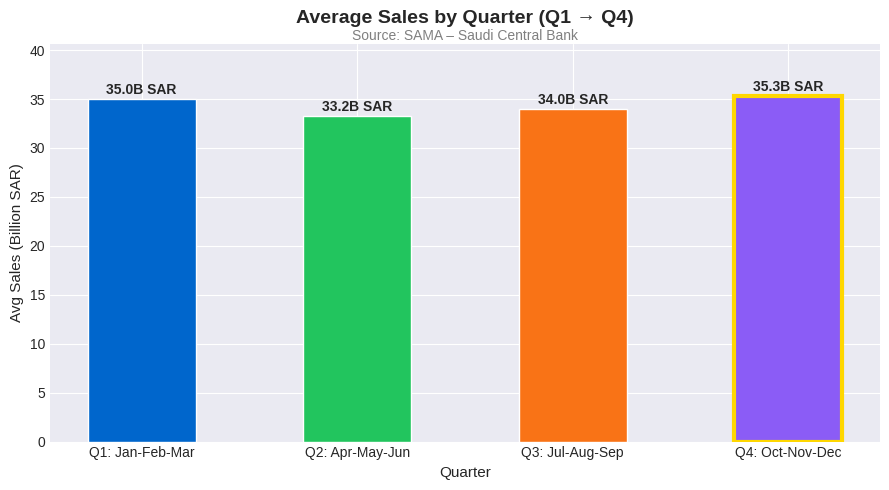

✅ Chart 5 fixed & saved!


In [12]:
# ================================================
# CHART 5: Quarterly Performance
# ================================================

# Fixed: sort by quarter number, not by sales value
quarterly_sorted = quarterly.sort_values('quarter')

fig, ax = plt.subplots(figsize=(9, 5))

quarter_colors = ['#0066CC', '#22c55e', '#f97316', '#8b5cf6']

bars = ax.bar(quarterly_sorted['quarter_name'],
              quarterly_sorted['avg_sales_billion'],
              color=quarter_colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, quarterly_sorted['avg_sales_billion']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'{val:.1f}B SAR',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

# Highlight best quarter
best_q = quarterly_sorted['avg_sales_billion'].idxmax()
bars[quarterly_sorted.index.get_loc(best_q)].set_edgecolor('gold')
bars[quarterly_sorted.index.get_loc(best_q)].set_linewidth(3)

ax.set_title('Average Sales by Quarter (Q1 → Q4)',
             fontsize=14, fontweight='bold', pad=15)
ax.text(0.5, 1.01, 'Source: SAMA – Saudi Central Bank',
        transform=ax.transAxes, ha='center', fontsize=10, color='gray')
ax.set_xlabel('Quarter', fontsize=11)
ax.set_ylabel('Avg Sales (Billion SAR)', fontsize=11)
ax.set_ylim(0, quarterly_sorted['avg_sales_billion'].max() * 1.15)

plt.tight_layout()
plt.savefig('/content/chart5_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 fixed & saved!")